In [1]:
import sys
sys.path.insert(0, "..")

CONFIG = "../configs/supervised/resnet18_asymmetric.yaml"
SEED   = 42
DEVICE = "cuda"   # change to "cpu" if no GPU available

In [2]:
from scripts.run_pipeline_debug import run

results = run(config_path=CONFIG, seed=SEED, device=DEVICE)
print(f"\nReturned {len(results)} result dicts.")

2026-08-17 13:17:15,112:WARNING:reborn:__init__:<module>:

                     WARNING!!!
Failed to import the fortran-based modules in reborn.
Your code might still work since only a few parts of reborn
use fortran code, but you should set up your system so that 
numpy.f2py compiles fortran correctly. The most common issues are:
1) Your system does not have a fortran compiler. Solution: 
   Use a package manager to install gfortran or similar.  Any
   sensible AI prompt should be able to provide instructions.
2) Your system does not have the meson build system, which is 
   required for numpy versions greater than 1.26.  Solution:
   Use a package manager to install meson.  Any sensible AI 
   prompt should be able to provide instructions.
3) You upgraded numpy from version 1 to version 2, resulting in
   incompatible modules.  Solution: wipe out all of the existing
   compiled code with the command 
   $ python -m reborn --cleanup_fortran
4) You have an old numpy version (<1.26) and


══════════════════════════════════════════════════════════════
SFX PREPROCESSING DEBUG RUN — 8 frames  seed=42  device=cuda
══════════════════════════════════════════════════════════════
  [ 1] AGIPD          compressed0.cxi  frame 0
  [ 2] JUNGFRAU_4M    compressed7.cxi  frame 877
  [ 3] JUNGFRAU_4M    compressed7.cxi  frame 1307
  [ 4] JUNGFRAU_4M    compressed7.cxi  frame 866
  [ 5] ePix10k        compressed3.cxi  frame 805
  [ 6] ePix10k        compressed3.cxi  frame 376
  [ 7] Eiger4M        compressed4.cxi  frame 2942
  [ 8] Eiger4M        compressed4.cxi  frame 3044

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FRAME 1/8  AGIPD  compressed0.cxi  frame 0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step  1] Read           0.987s  shape=(16, 512, 128)  dtype=float32  true_label=0
  [Step  2] Geometry       AGIPD 1M  (128 panels)
  [Step  3] Assembly       0.113s  shape=(1273, 1273)  min=0  max=4182
  [Step  4] Hitfinder      GPUHitfinder (gp

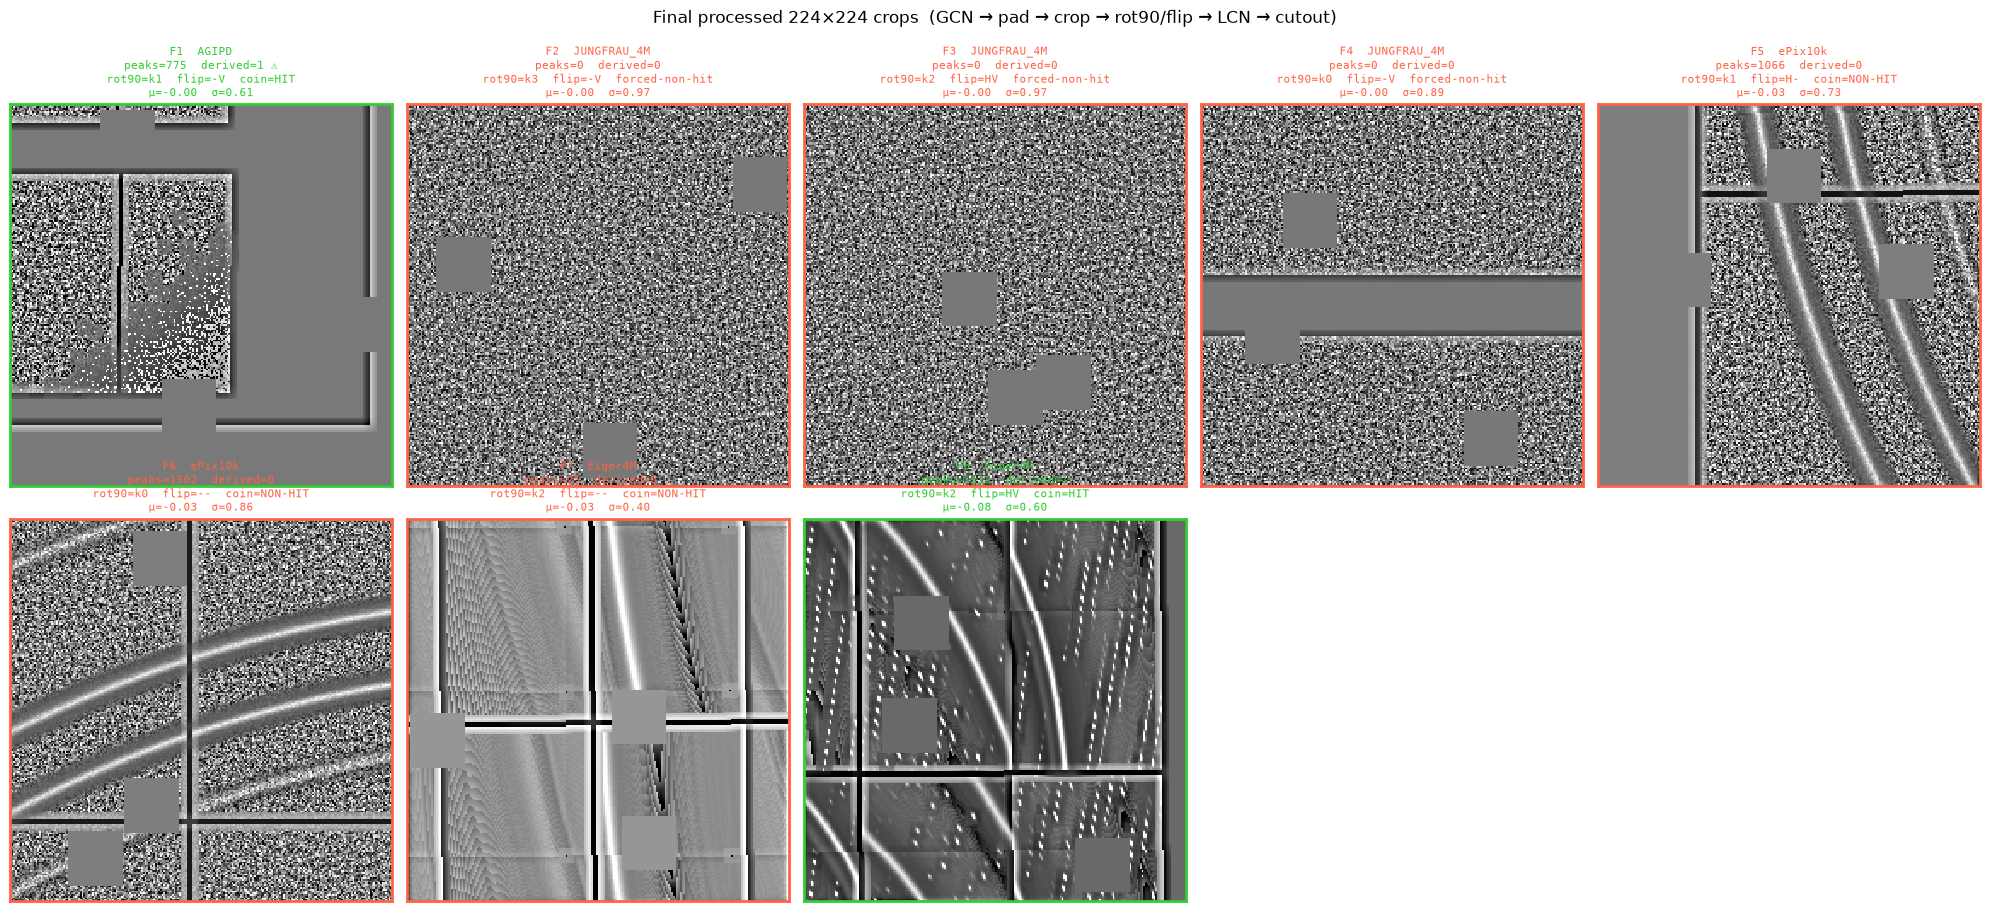

In [3]:
import matplotlib.pyplot as plt
import numpy as np

n = len(results)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4.5))
axes = np.array(axes).flatten()

for ax, r in zip(axes, results):
    img = r["tensor"].squeeze(0).numpy()          # (224, 224) float32
    vmin, vmax = np.percentile(img, [2, 98])
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, origin="upper",
              interpolation="nearest")

    hit_color = "limegreen" if r["derived_label"] == 1 else "tomato"
    mismatch  = " ⚠" if r["label_mismatch"] else ""
    aug       = r["augment"]
    flip_str  = ("H" if aug["flip_h"] else "-") + ("V" if aug["flip_v"] else "-")
    crop_short = r["crop_decision"].split("  ")[0]

    title = (
        f"F{r['frame_no']}  {r['detector']}\n"
        f"peaks={r['n_peaks']}  derived={r['derived_label']}{mismatch}\n"
        f"rot90=k{aug['rot90_k']}  flip={flip_str}  {crop_short}\n"
        f"μ={img.mean():.2f}  σ={img.std():.2f}"
    )
    ax.set_title(title, fontsize=8, color=hit_color, family="monospace")

    for spine in ax.spines.values():
        spine.set_edgecolor(hit_color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
    "Final processed 224×224 crops  (GCN → pad → crop → rot90/flip → LCN → cutout)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        "frame":         r["frame_no"],
        "detector":      r["detector"],
        "file":          r["file"],
        "frame_idx":     r["frame_idx"],
        "true_label":    r["true_label"],
        "n_peaks":       r["n_peaks"],
        "mismatch":      "⚠" if r["label_mismatch"] else "✓",
        "crop":          r["crop_decision"].split("  ")[0],
        "derived_label": r["derived_label"],
        "rot90_k":       r["augment"]["rot90_k"],
        "flip":          ("H" if r["augment"]["flip_h"] else "-") + ("V" if r["augment"]["flip_v"] else "-"),
        "gcn_max":       round(r["gcn_stats"]["max"], 2),
        "lcn_std":       round(r["lcn_stats"]["std"], 3),
        "assemble_ms":   round(r["assembly_time_s"] * 1000, 1),
    })

df = pd.DataFrame(rows).set_index("frame")
pd.set_option("display.max_colwidth", 30)
display(df)

,detector,file,frame_idx,true_label,n_peaks,mismatch,crop,derived_label,rot90_k,flip,gcn_max,lcn_std,assemble_ms
frame,,,,,,,,,,,,,
1,AGIPD,compressed0.cxi,0,0,775,⚠,coin=HIT,1,1,-V,3.53,0.618,112.9
2,JUNGFRAU_4M,compressed7.cxi,877,0,0,✓,forced-non-hit,0,3,-V,7.95,0.999,0.0
3,JUNGFRAU_4M,compressed7.cxi,1307,0,0,✓,forced-non-hit,0,2,HV,15.04,0.999,0.0
4,JUNGFRAU_4M,compressed7.cxi,866,0,0,✓,forced-non-hit,0,0,-V,4.70,0.916,0.0
5,ePix10k,compressed3.cxi,805,1,1066,✓,coin=NON-HIT,0,1,H-,9.34,0.752,227.7
6,ePix10k,compressed3.cxi,376,1,1502,✓,coin=NON-HIT,0,0,--,8.29,0.892,241.8
7,Eiger4M,compressed4.cxi,2942,0,25,⚠,coin=NON-HIT,0,2,--,8.08,0.424,257.0
8,Eiger4M,compressed4.cxi,3044,1,1112,✓,coin=HIT,1,2,HV,47.07,0.617,262.1


## LCN ε ablation — fixing noise explosion on low-variance patches

The JUNGFRAU_4M non-hit crops above (`lcn_std ≈ 1.0` with zero peaks) show salt-and-pepper
static: in background-only regions the local σ after GCN is nearly zero, and LCN's old
std-form denominator (`σ_W + 1e-6`) amplified readout noise to unit variance. `lcn()` now
uses the variance form `(I − μ_W) / sqrt(σ²_W + ε)`, which floors the denominator at `sqrt(ε)`.

This sweep picks ε empirically: **rows** = the three JUNGFRAU non-hit frames plus one hit
frame (signal-preservation control), **columns** = ε values. Selection rule: the smallest ε
that eliminates the static on the non-hit patches while the hit patch's Bragg peaks remain
clearly visible.

In [ ]:
from src.preprocessing.normalize import lcn

EPS_SWEEP = [1e-6, 1e-4, 1e-3, 1e-2, 1e-1]

# Ablation frames: all no-peak non-hits (the static cases) + one hit as signal control
noise_frames = [r for r in results if r["n_peaks"] == 0 and r["derived_label"] == 0]
hit_frames   = [r for r in results if r["derived_label"] == 1 and r["n_peaks"] > 0]
ablation_frames = noise_frames + hit_frames[-1:]   # e.g. F2–F4 + F8

nrows, ncols = len(ablation_frames), len(EPS_SWEEP)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.4))
axes = np.atleast_2d(axes)

stats_rows = []
for i, r in enumerate(ablation_frames):
    pre = r["crop_pre_lcn"]
    kind = "HIT" if r["derived_label"] == 1 else "non-hit"
    for j, eps in enumerate(EPS_SWEEP):
        out = lcn(pre, eps=eps)
        vmin, vmax = np.percentile(out, [2, 98])
        ax = axes[i, j]
        ax.imshow(out, cmap="gray", vmin=vmin, vmax=vmax, origin="upper",
                  interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(f"ε = {eps:g}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"F{r['frame_no']} {r['detector']}\n({kind})",
                          fontsize=8, family="monospace")
        stats_rows.append({
            "frame": r["frame_no"], "detector": r["detector"], "kind": kind,
            "eps": eps, "out_std": round(float(out.std()), 3),
            "out_max": round(float(out.max()), 2),
        })

fig.suptitle("LCN ε sweep — variance form (I − μ_W) / sqrt(σ²_W + ε)", fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

stats = pd.DataFrame(stats_rows).pivot_table(
    index=["frame", "detector", "kind"], columns="eps", values=["out_std", "out_max"]
)
display(stats)

### Selection

**Rule:** pick the smallest ε where the non-hit rows show smooth background (no
salt-and-pepper static, `out_std` well below 1) while the HIT row's Bragg peaks stay
clearly visible (high `out_max` relative to background).

**Chosen ε = 1e-2** (headless sweep on F2–F4 JUNGFRAU non-hits + F8 Eiger hit,
2026-08-17):

| case | pre-LCN σ | out_std @1e-6 | @1e-3 | @1e-2 | @1e-1 |
|---|---|---|---|---|---|
| JF non-hit, pure background (σ=0.014) | 0.014 | 1.00 (static) | 0.38 | **0.13** | 0.04 |
| JF non-hit, moderate texture (σ=0.24) | 0.24 | 1.00 | 0.98 | **0.83** | 0.43 |
| Eiger HIT (peak out_max) | — | 7.3 | 7.2 | **7.1** | 6.8 |

ε=1e-2 floors the denominator at 0.1 GCN units: pure-background noise drops from unit
variance to 0.13, moderate-contrast texture is barely affected, and Bragg peak amplitude
is fully preserved. ε=1e-3 still leaves background at 0.38 std; ε=1e-1 starts flattening
genuine texture. `LCN_EPSILON = 1e-2` is now the default in
`src/preprocessing/normalize.py`, picked up by all call sites (training, eval, debug
runner). **Note:** display cells use 2–98 percentile scaling, which visually re-stretches
suppressed noise — judge by the `out_std` numbers, not apparent contrast.